<H1> Logistic Regression </H1>
<h3> This notebook contains implementation of logistic regression using the dataset of the sepal and petal length and width of 150 iris flower of three different species "Iris setosa", "Iris versicolor" and "Iris virginica".

In [9]:
# Step 1: load the data and takea quick peek.
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris(as_frame = True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [2]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
iris.target.head(5)

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [12]:
# Step 2: Split the data and train a logistic regression model on the training set.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(x_train, y_train)

x_new = np.linspace(0,3,100).reshape(-1,1)
y_proba = log_reg.predict_proba(x_new)
decision_boundary = x_new[y_proba[:,1] >= 0.5][0,0]

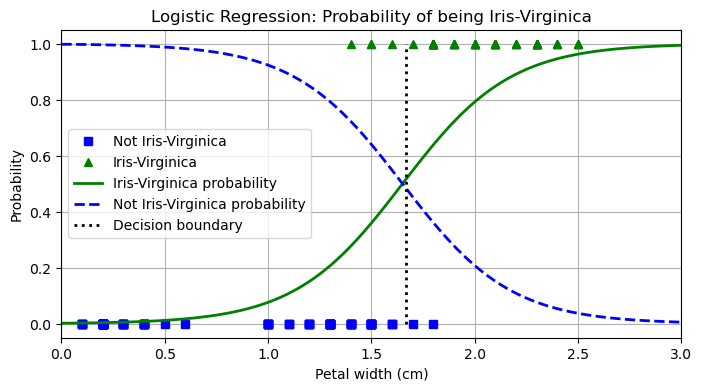

In [14]:
import matplotlib.pyplot as plt
# Plot the probability curve
plt.figure(figsize=(8, 4))

# Plot the training data points
plt.plot(x[y==0], y[y==0], "bs", label="Not Iris-Virginica")  # blue squares
plt.plot(x[y==1], y[y==1], "g^", label="Iris-Virginica")      # green triangles

# Plot the predicted probabilities
plt.plot(x_new, y_proba[:, 1], "g-", linewidth=2, label="Iris-Virginica probability")
plt.plot(x_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris-Virginica probability")

# Mark the decision boundary
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")

# Customize the plot
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.title("Logistic Regression: Probability of being Iris-Virginica")
plt.legend(loc="center left")
plt.grid(True)
plt.axis([0, 3, -0.05, 1.05])

# Display the plot
plt.show()

In [15]:
# Make predictions on new data
new_flower = [[1.5], [2.5]]  # two flowers with petal widths 1.5cm and 2.5cm
predictions = log_reg.predict(new_flower)
probabilities = log_reg.predict_proba(new_flower)

print("\nPredictions for new flowers:")
for width, pred, prob in zip(new_flower, predictions, probabilities):
    print(f"Petal width {width[0]} cm → {'Virginica' if pred == 1 else 'Not Virginica'} "
          f"(probability of being Virginica: {prob[1]:.3f})")


Predictions for new flowers:
Petal width 1.5 cm → Not Virginica (probability of being Virginica: 0.360)
Petal width 2.5 cm → Virginica (probability of being Virginica: 0.963)
